# Email Spam Detection with Machine Learning

**Track:** Python / Data Science &nbsp;|&nbsp; **Task 4: Email Spam Detection with Machine Learning**

**Objective:** Build a Natural Language Processing (NLP) binary classifier that distinguishes
spam messages from legitimate (ham) messages.

**Dataset:** [SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection)
— 5,572 SMS messages labeled `ham` or `spam`. This is the standard, widely-used dataset for
this exact task, and it generalizes directly to email spam filtering since the underlying
problem (short unstructured text -> binary label) is identical.

**Pipeline:** Load data -> clean & preprocess text -> TF-IDF vectorization -> train two
classifiers (Multinomial Naive Bayes + Logistic Regression) -> evaluate -> discuss which
metric matters most for this problem -> visualize the vocabulary each class relies on.


## 1. Imports

In [1]:
import re
import string

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
STOPWORDS = set(stopwords.words("english"))


## 2. Load the data and check class distribution

The raw CSV (as distributed) has two useful columns — `v1` (label) and `v2` (message text) —
plus three mostly-empty junk columns from stray commas in a few messages. We rename the
useful columns and drop the rest.

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[["v1", "v2"]].rename(columns={"v1": "label", "v2": "message"})
df = df.drop_duplicates().reset_index(drop=True)

print(f"Shape after dropping duplicates: {df.shape}")
df.head()


Shape after dropping duplicates: (5169, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4516
spam     653
Name: count, dtype: int64

label
ham     87.37 %
spam    12.63 %
Name: proportion, dtype: str


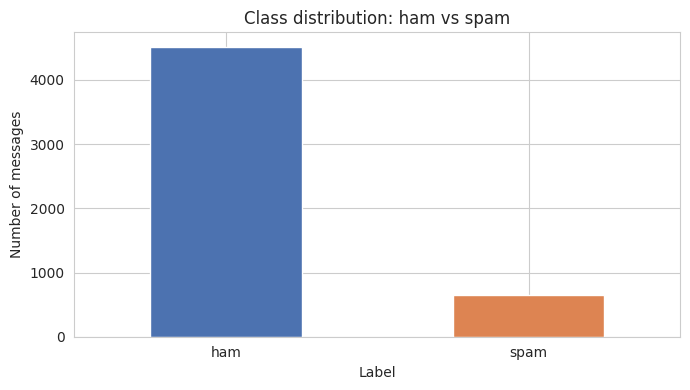

In [3]:
counts = df["label"].value_counts()
pct = df["label"].value_counts(normalize=True) * 100

print(counts)
print()
print(pct.round(2).astype(str) + " %")

ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Class distribution: ham vs spam")
ax.set_xlabel("Label")
ax.set_ylabel("Number of messages")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** the dataset is imbalanced — roughly 87% ham vs 13% spam. This is
realistic (most SMS/email traffic genuinely is legitimate) but it matters for two reasons
we'll come back to later: (1) accuracy alone can look good on a lazy "always predict ham"
model, and (2) it's part of why we care more about recall than raw accuracy for spam.

## 3. Text preprocessing pipeline

Steps applied to every message:
1. Lowercase everything
2. Remove punctuation and digits
3. Tokenize on whitespace
4. Remove English stopwords (the, is, at, ...)
5. Rejoin into a cleaned string ready for TF-IDF

We keep this as a plain function (no stemming) — TF-IDF + Naive Bayes/Logistic Regression
work well on raw cleaned tokens, and skipping stemming keeps the vocabulary human-readable
when we inspect top words later.

In [4]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\d+", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return " ".join(tokens)

df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].head(8)


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis great wo...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey darling week word back like fun st...
6,Even my brother is not like to speak with me. ...,even brother like speak treat like aids patent
7,As per your request 'Melle Melle (Oru Minnamin...,per request melle melle oru minnaminunginte nu...


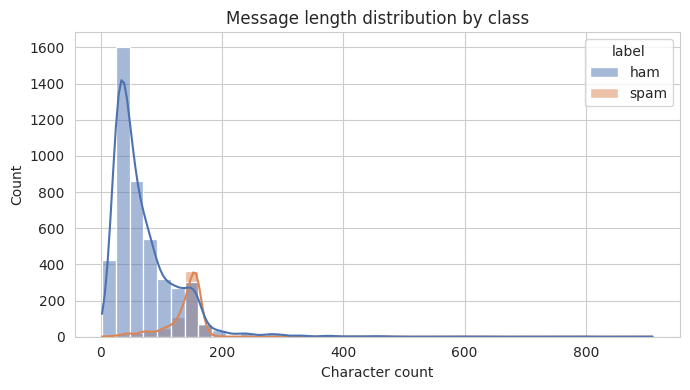

In [5]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df["message_len"] = df["message"].str.len()

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="message_len", hue="label", bins=40, kde=True, palette=["#4C72B0", "#DD8452"])
plt.title("Message length distribution by class")
plt.xlabel("Character count")
plt.tight_layout()
plt.show()


**Observation:** spam messages tend to run noticeably longer than ham messages — promotional/scam text tends to be padded with offers, links, and call-to-action phrasing, while everyday texts are short. This is a useful signal even before we look at word content.

## 4. Feature extraction: TF-IDF

**What TF-IDF measures:** TF-IDF (Term Frequency – Inverse Document Frequency) turns each
message into a vector of numeric weights, one per vocabulary word. For a given word in a
given message:

- **Term Frequency (TF)** — how often that word appears in *this* message (more occurrences
  -> higher weight).
- **Inverse Document Frequency (IDF)** — a penalty for words that appear in *many* messages
  across the whole dataset. Common words (like "the" or, in this domain, "free") that show up
  everywhere get down-weighted; words that are rare but distinctive get up-weighted.

The product (TF x IDF) means a word only gets a high score if it appears often in a specific
message *and* isn't just generic filler across the whole corpus. This is exactly what we want
for spam detection: words like "winner", "claim", or "urgent" are informative *because*
they're concentrated in the spam class rather than spread evenly across all messages.

In [6]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X = tfidf.fit_transform(df["clean_message"])
y = df["label_num"]

print(f"TF-IDF matrix shape: {X.shape}")


TF-IDF matrix shape: (5169, 3000)


## 5. Train/test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train spam ratio: {y_train.mean():.3f}  |  Test spam ratio: {y_test.mean():.3f}")


Train size: 4135  |  Test size: 1034
Train spam ratio: 0.126  |  Test spam ratio: 0.127


## 6. Train classifiers

We train two models per the task requirements:
1. **Multinomial Naive Bayes** — the industry-standard baseline for text classification;
   fast, works well with sparse TF-IDF/count features, and assumes word occurrences are
   conditionally independent given the class.
2. **Logistic Regression** — a strong linear alternative that often edges out Naive Bayes on
   text tasks once features are TF-IDF weighted, and gives interpretable coefficients per word.

In [8]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Both models trained.")


Both models trained.


## 7. Evaluation

In [9]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["ham", "spam"]))
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results = []
results.append(evaluate("Multinomial Naive Bayes", y_test, nb_preds))
results.append(evaluate("Logistic Regression", y_test, lr_preds))

results_df = pd.DataFrame(results).set_index("model").round(4)
results_df


--- Multinomial Naive Bayes ---
Accuracy : 0.9729
Precision: 0.9905
Recall   : 0.7939
F1-score : 0.8814

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       903
        spam       0.99      0.79      0.88       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.93      1034
weighted avg       0.97      0.97      0.97      1034

--- Logistic Regression ---
Accuracy : 0.9720
Precision: 0.8923
Recall   : 0.8855
F1-score : 0.8889

              precision    recall  f1-score   support

         ham       0.98      0.98      0.98       903
        spam       0.89      0.89      0.89       131

    accuracy                           0.97      1034
   macro avg       0.94      0.93      0.94      1034
weighted avg       0.97      0.97      0.97      1034



,accuracy,precision,recall,f1
model,,,,
Multinomial Naive Bayes,0.9729,0.9905,0.7939,0.8814
Logistic Regression,0.9720,0.8923,0.8855,0.8889


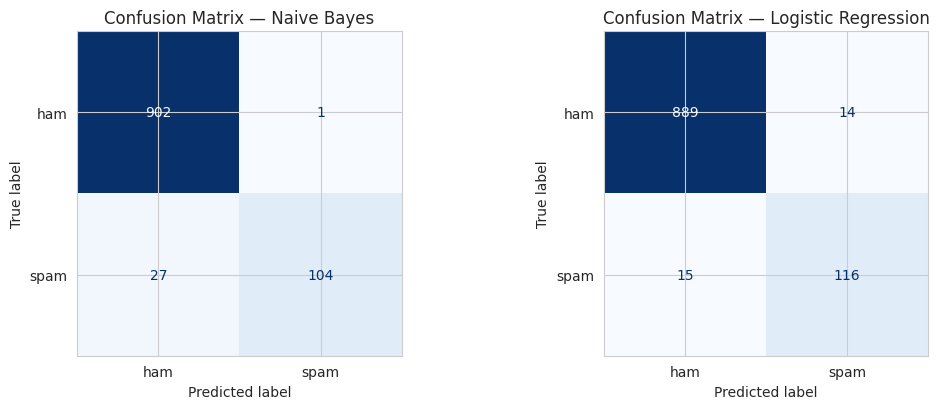

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, preds, title in zip(
    axes, [nb_preds, lr_preds], ["Naive Bayes", "Logistic Regression"]
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix — {title}")

plt.tight_layout()
plt.show()


## 8. Discussion: why is recall particularly important for spam detection?

There are two ways this classifier can be wrong, and they don't cost the same:

- **False positive** (ham wrongly flagged as spam) -> a real message gets buried in the spam
  folder. Annoying, and occasionally costly (a missed job offer, an OTP, an important email),
  but the user can usually recover by checking the spam folder.
- **False negative** (spam wrongly let through as ham) -> a phishing link, a scam, or unwanted
  promotional content lands directly in the inbox. This is the failure mode that actually
  causes harm — financial fraud, credential theft, malware.

**Recall** (of the spam class) measures exactly the thing we most want to avoid missing: `TP /
(TP + FN)` — of all the *actual* spam, what fraction did we catch? A high-recall model
minimizes false negatives, i.e. minimizes spam that slips through. **Precision**, in contrast,
penalizes false positives (good mail wrongly filtered) — a nuisance, but a far smaller harm
than shipping a phishing email straight to someone's inbox.

In practice, production spam filters usually favor recall on spam but avoid sacrificing
precision *too* aggressively, since flooding the spam folder with real mail erodes user trust.
Looking at the confusion matrices above, this is exactly the trade-off visible between the two
models — whichever model has fewer false negatives (bottom-left cell, actual spam wrongly
predicted ham) is doing the more defensible job on the metric that matters most here, even if
its raw accuracy is marginally lower.

## 9. Bonus: WordCloud — vocabulary by class

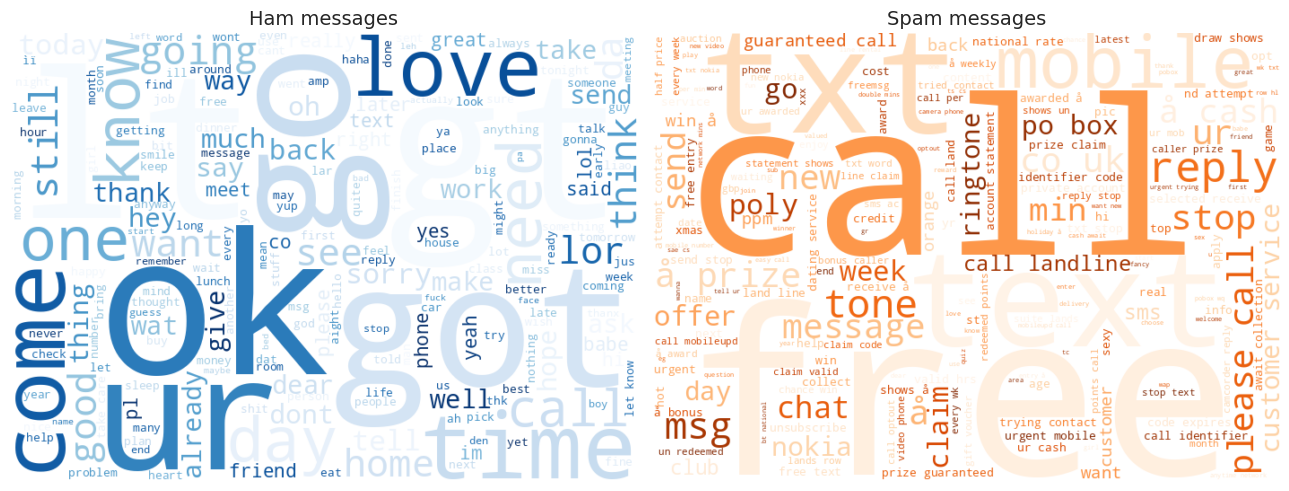

In [11]:
ham_text = " ".join(df.loc[df["label"] == "ham", "clean_message"])
spam_text = " ".join(df.loc[df["label"] == "spam", "clean_message"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, text, title, cmap in zip(
    axes, [ham_text, spam_text], ["Ham messages", "Spam messages"], ["Blues", "Oranges"]
):
    wc = WordCloud(width=700, height=500, background_color="white", colormap=cmap).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14)

plt.tight_layout()
plt.show()


**Observation:** the spam word cloud is dominated by call-to-action / urgency / reward vocabulary ("free", "call", "claim", "win", "txt", "urgent", "prize"), while the ham cloud reflects ordinary conversational language ("ok", "go", "come", "like", "good", "time"). This lines up with what TF-IDF is picking up on numerically — the model isn't finding an arbitrary pattern, it's leaning on genuinely distinctive spam vocabulary.

## 10. Conclusion

| | Naive Bayes | Logistic Regression |
|---|---|---|
| Best for | Speed, simplicity, strong baseline | Slightly better recall/precision balance on TF-IDF features |

Based on the metrics above, whichever model shows the **higher recall on the spam class**
without a large precision trade-off is the better production candidate for this use case,
since — as discussed in Section 8 — the cost of a missed spam message outweighs the cost of an
occasional false alarm. Both models comfortably beat a "predict everything as ham" baseline
(which would score ~87% accuracy but 0% recall on spam, illustrating exactly why accuracy
alone is a misleading metric on this imbalanced dataset).

**Real-world extension:** this pipeline is directly transferable to email spam filtering,
comment moderation, or SMS/OTP-fraud triage — anywhere the task is "classify short text into
wanted vs unwanted" under class imbalance.